In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


In [14]:
# Paso 1 - Cargar el dataset
url = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"

In [15]:
df = pd.read_csv(url, sep=",")
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [16]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [17]:
# Solo nos interesan las columnas Latitude, Longitude y MedInc

df_processed = df[['MedInc','Latitude','Longitude']]
df_processed.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


In [18]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split

X = df_processed

X_train, X_test, = train_test_split(X, test_size=0.3, random_state=42)


X_train.head()

,MedInc,Latitude,Longitude
7061,4.1312,33.93,-118.02
14689,2.8631,32.79,-117.09
17323,4.2026,34.59,-120.14
10056,3.1094,39.26,-121.00
15750,3.3068,37.77,-122.45


In [19]:
# Paso 2: Construye un K-Means

# Entrenar el modelo
model = KMeans(n_clusters = 6, random_state = 42)
model.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [20]:
# Almacenar el clauster al que pertenece cada casa en una nueva columna
X_train['Cluster'] = model.labels_
X_train.head()

,MedInc,Latitude,Longitude,Cluster
7061,4.1312,33.93,-118.02,1
14689,2.8631,32.79,-117.09,1
17323,4.2026,34.59,-120.14,0
10056,3.1094,39.26,-121.00,5
15750,3.3068,37.77,-122.45,5


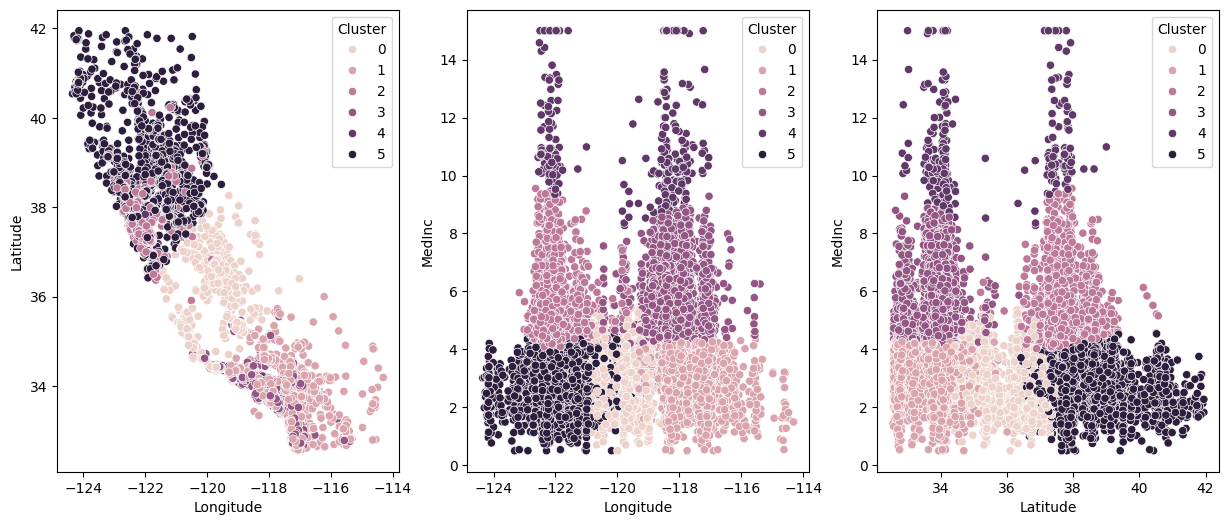

In [21]:
# Graficar los clusters en un diagrama de puntos

fig, ax = plt.subplots(1,3, figsize=(15, 6))
sns.scatterplot(x=X_train['Longitude'], y=X_train['Latitude'], hue=X_train['Cluster'], ax=ax[0])
sns.scatterplot(x=X_train['Longitude'], y=X_train['MedInc'], hue=X_train['Cluster'], ax=ax[1])
sns.scatterplot(x=X_train['Latitude'], y=X_train['MedInc'], hue=X_train['Cluster'], ax=ax[2])   
plt.show()

In [22]:
# Paso 3: Predice con el conjunto de test

X_test['Cluster'] = model.predict(X_test)
X_test.head()

,MedInc,Latitude,Longitude,Cluster
20046,1.6812,36.06,-119.01,0
3024,2.5313,35.14,-119.46,0
15663,3.4801,37.80,-122.44,5
20484,5.7376,34.28,-118.72,3
9814,3.7250,36.62,-121.93,5


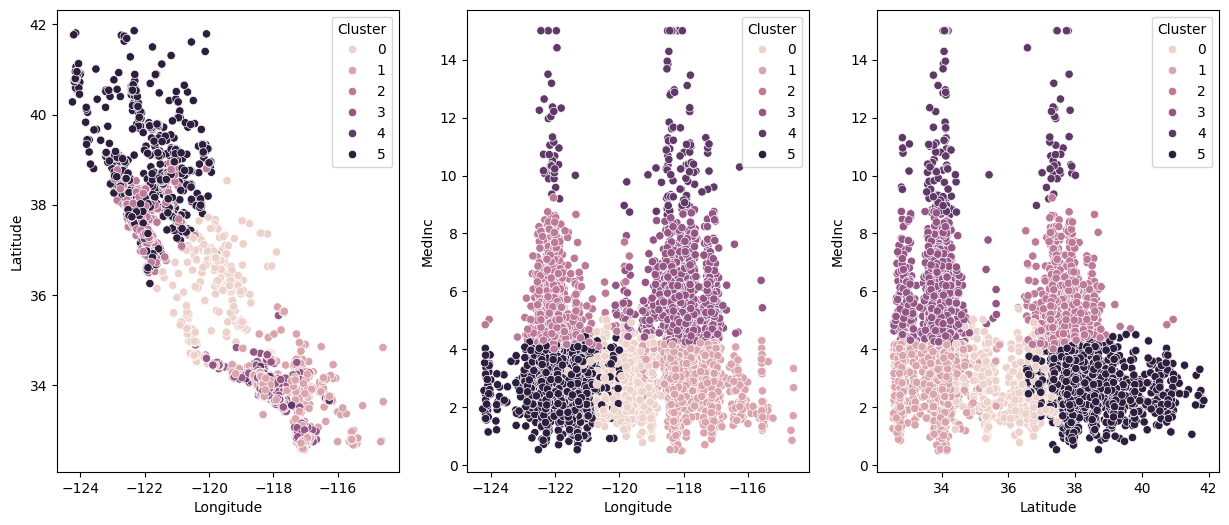

In [23]:
# Graficar los clusters en un diagrama de puntos con el conjunto de test

fig, ax = plt.subplots(1,3, figsize=(15, 6))
sns.scatterplot(x=X_test['Longitude'], y=X_test['Latitude'], hue=X_test['Cluster'], ax=ax[0])
sns.scatterplot(x=X_test['Longitude'], y=X_test['MedInc'], hue=X_test['Cluster'], ax=ax[1])
sns.scatterplot(x=X_test['Latitude'], y=X_test['MedInc'], hue=X_test['Cluster'], ax=ax[2])   
plt.show()


In [24]:
# Paso 4: Entrena un modelo de clasificación supervisada
# Voy a utilizar Random Forest para evitar el sobreajuste en base al tamaño del conjunto de datos

from sklearn.ensemble import RandomForestClassifier
# Entrenar el modelo

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train.drop('Cluster', axis=1), X_train['Cluster'])   


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
# Predecir con el conjunto de test

y_pred = rf_model.predict(X_test.drop('Cluster', axis=1))

# Evaluar el modelo

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(X_test['Cluster'], y_pred))
print(confusion_matrix(X_test['Cluster'], y_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       495
           1       1.00      1.00      1.00      2195
           2       0.99      1.00      0.99       806
           3       0.99      1.00      1.00      1123
           4       1.00      0.98      0.99       132
           5       1.00      0.99      0.99      1441

    accuracy                           1.00      6192
   macro avg       0.99      0.99      0.99      6192
weighted avg       1.00      1.00      1.00      6192

[[ 489    0    0    2    0    4]
 [   1 2191    0    3    0    0]
 [   1    0  803    0    0    2]
 [   1    3    0 1119    0    0]
 [   0    0    2    1  129    0]
 [   1    0    8    0    0 1432]]


Podemos ver muy buenos resultados con este modelo

In [27]:
# Paso 5: Guarda los modelos

import pickle

with open('../models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)